In [3]:
# @title AI prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

In [25]:
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model


In [26]:
input_images = Input(shape=(28, 28, 1))
x = Conv2D(32, (3, 3), padding = 'same')(input_images)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3,3), padding='same')(x)
encoded = MaxPooling2D((2, 2))(x)
# at this point the representation is (7,7,64)

d = Conv2D(64, (3,3), padding='same')(encoded)
d = UpSampling2D((2, 2))(d)
d = Conv2D(32, (3,3), padding='same')(d)
d = UpSampling2D((2, 2))(d)
decoded = Conv2D(1, (3,3), activation = 'sigmoid',padding='same')(d)

autoencoder = Model(input_images, decoded)
autoencoder.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from tensorflow.keras.datasets import mnist
import numpy as np

In [28]:
(xtrain, _), (xtest,_)  = mnist.load_data()

In [29]:
xtrain = xtrain/255
xtest = xtest/255

# adding axis 1 since there are black and white images
xtrain = xtrain.reshape(len(xtrain), 28,28,1)
xtest = xtest.reshape(len(xtest),28,28,1)


In [30]:
xtrain.shape, xtest.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [31]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [32]:
autoencoder.fit(xtrain, xtrain,
                epochs=2,
                batch_size=128,
                )

Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 148s 310ms/step - loss: 0.1587
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 195s 295ms/step - loss: 0.0736


In [35]:
encoder = Model(input_images, encoded)
encoder.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
encoded_images = encoder.predict(xtest)
encoded_images.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


(10000, 7, 7, 64)

In [37]:
encoder.layers

[<InputLayer name=input_layer_3, built=True>,
 <Conv2D name=conv2d_15, built=True>,
 <MaxPooling2D name=max_pooling2d_6, built=True>,
 <Conv2D name=conv2d_16, built=True>,
 <MaxPooling2D name=max_pooling2d_7, built=True>]

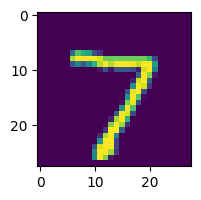

In [50]:
import matplotlib.pyplot as plt
plt.figure(figsize=(2,2))
plt.imshow(xtest[0])

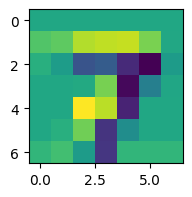

In [48]:
plt.figure(figsize=(2,2))
plt.imshow(encoded_images[0,:,:,0])

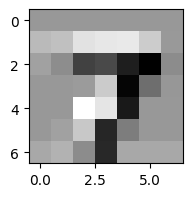

In [49]:
plt.figure(figsize=(2,2))
plt.imshow(encoded_images[0,:,:,0], cmap='gray')

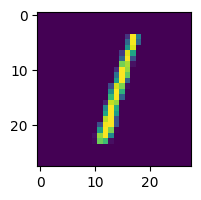

In [53]:
plt.figure(figsize=(2,2))
plt.imshow(xtest[2])

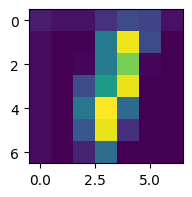

In [54]:
plt.figure(figsize=(2,2))
plt.imshow(encoded_images[2,:,:,1])

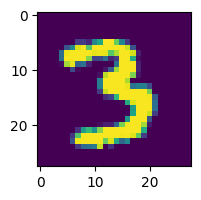

In [55]:
plt.figure(figsize=(2,2))
plt.imshow(xtest[500])

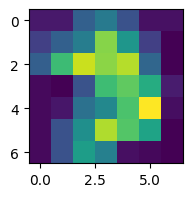

In [59]:
plt.figure(figsize=(2,2))
plt.imshow(encoded_images[500,:,:,1])

In [62]:
d_input_imgs = Input(shape = (7,7,64))
d = autoencoder.layers[5](d_input_imgs)
d = autoencoder.layers[6](d)
d = autoencoder.layers[7](d)
d = autoencoder.layers[8](d)
decoder_output = autoencoder.layers[9](d)
decoder = Model(d_input_imgs, decoder_output)
decoder.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,681 (217.50 KB)

 Trainable params: 55,681 (217.50 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
decoded_images = decoder.predict(encoded_images)
decoded_images.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


(10000, 28, 28, 1)

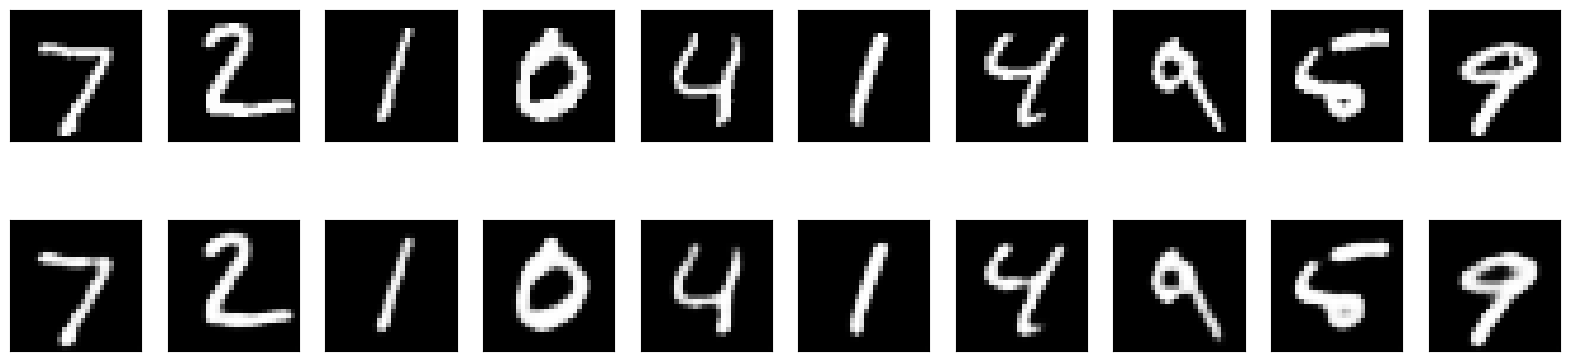

In [64]:
import matplotlib.pyplot as plt

n = 10  # how many digits we will display
plt.figure(figsize=(20, 5))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(xtest[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_images[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

### Testing with own created image

In [67]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img_path = 'my_six.jpg'
img = Image.open(img_path).convert('L') # Convert to grayscale
img = img.resize((28, 28)) # Resize to 28x28

# Convert to numpy array and normalize
img_array = np.asarray(img)
img_array = img_array / 255.0

# Reshape for the model (add batch dimension and channel dimension)
img_array = img_array.reshape(1, 28, 28, 1)

print("Original image shape:", img_array.shape)

Original image shape: (1, 28, 28, 1)


In [68]:
# Encode the image
encoded_img = encoder.predict(img_array)
print("Encoded image shape:", encoded_img.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Encoded image shape: (1, 7, 7, 64)


In [69]:
# Decode the image
decoded_img = decoder.predict(encoded_img)
print("Decoded image shape:", decoded_img.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Decoded image shape: (1, 28, 28, 1)


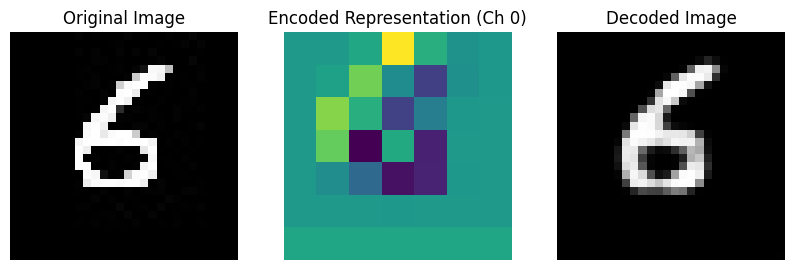

In [70]:
# Display the original, encoded, and decoded images
plt.figure(figsize=(10, 3))

# Original Image
ax = plt.subplot(1, 3, 1)
plt.imshow(img_array.reshape(28, 28), cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Encoded Image (display the first channel of the encoded representation)
ax = plt.subplot(1, 3, 2)
plt.imshow(encoded_img[0, :, :, 0], cmap='viridis') # Display one channel for visualization
plt.title('Encoded Representation (Ch 0)')
plt.axis('off')

# Decoded Image
ax = plt.subplot(1, 3, 3)
plt.imshow(decoded_img.reshape(28, 28), cmap='gray')
plt.title('Decoded Image')
plt.axis('off')

plt.show()

### OR

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


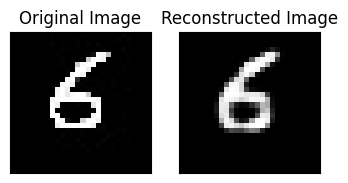

In [72]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img_path = 'my_six.jpg'


# Target size should be 28x28 pixels for MNIST-like input
img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')

img_array = image.img_to_array(img)
img_array = img_array.astype('float32') / 255.

img_flat = img_array.reshape(1, 28,28,1)

encoded_img = encoder.predict(img_flat)
decoded_img = decoder.predict(encoded_img)

plt.figure(figsize=(4, 4))

# Original Image
ax = plt.subplot(1, 2, 1)
plt.imshow(img_array.reshape(28, 28), cmap='gray')
plt.title('Original Image')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

# Reconstructed Image
ax = plt.subplot(1, 2, 2)
plt.imshow(decoded_img.reshape(28, 28), cmap='gray')
plt.title('Reconstructed Image')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

plt.show()

### Code to convert noisy images into clear.

In [73]:
# add noise
noise_factor = 0.5
xtrain_noisy = xtrain + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=xtrain.shape)
xtest_noisy = xtest + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=xtest.shape)

xtrain_noisy = np.clip(xtrain_noisy, 0., 1.)
xtest_noisy = np.clip(xtest_noisy, 0., 1.)

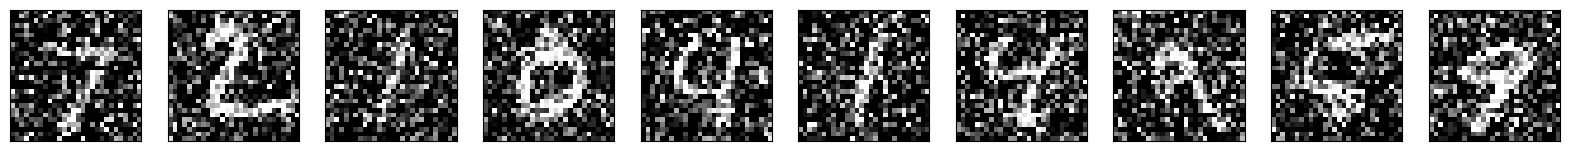

In [84]:
n = 10
plt.figure(figsize=(20, 5))
for i in range(n):

  ax = plt.subplot(2, n, i + 1)
  plt.imshow(xtest_noisy[i].reshape(28, 28))
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)





In [83]:
autoencoder.fit(xtrain_noisy, xtrain, epochs=2, batch_size=128)

Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 150s 320ms/step - loss: 0.1533
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 148s 315ms/step - loss: 0.1137


In [87]:
noisy_images = encoder.predict(xtest_noisy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [88]:
good_images = decoder.predict(noisy_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


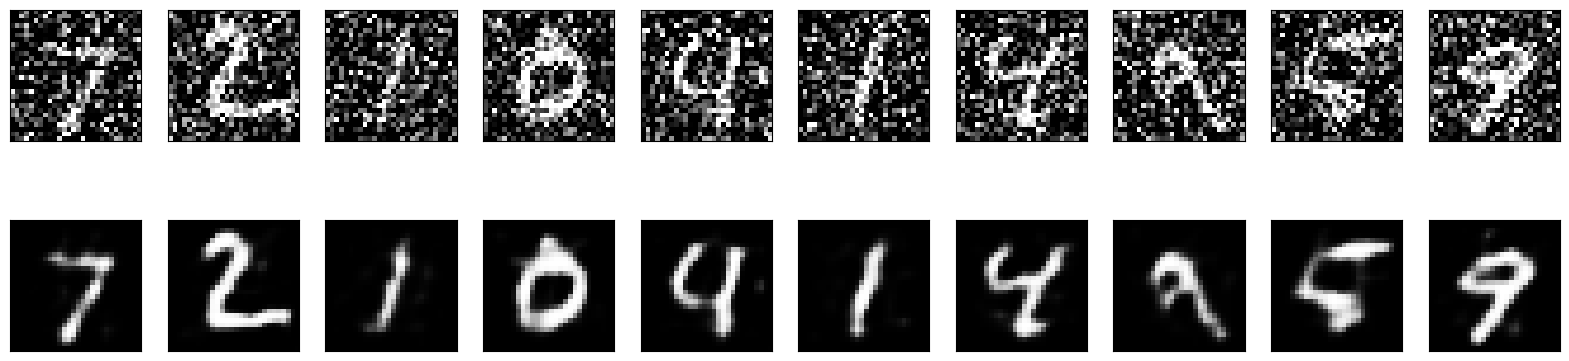

In [91]:
import matplotlib.pyplot as plt

n = 10  # how many digits we will display
plt.figure(figsize=(20, 5))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(xtest_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(good_images[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

### Test with own image with added noise

Original image shape: (1, 28, 28, 1)
Noisy image shape: (1, 28, 28, 1)


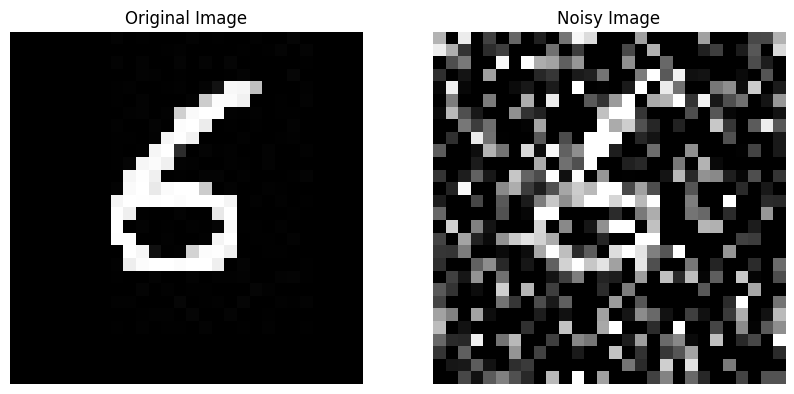

In [92]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img_path = 'my_six.jpg'
img = Image.open(img_path).convert('L') # Convert to grayscale
img = img.resize((28, 28)) # Resize to 28x28

# Convert to numpy array and normalize
img_array_orig = np.asarray(img)
img_array_orig = img_array_orig / 255.0

# Reshape for the model (add batch dimension and channel dimension)
img_array_orig = img_array_orig.reshape(1, 28, 28, 1)

# Add noise
noise_factor = 0.5
img_array_noisy = img_array_orig + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=img_array_orig.shape)
img_array_noisy = np.clip(img_array_noisy, 0., 1.)

print("Original image shape:", img_array_orig.shape)
print("Noisy image shape:", img_array_noisy.shape)

# Display original and noisy image
plt.figure(figsize=(10, 5))

ax = plt.subplot(1, 2, 1)
plt.imshow(img_array_orig.reshape(28, 28), cmap='gray')
plt.title('Original Image')
plt.axis('off')

ax = plt.subplot(1, 2, 2)
plt.imshow(img_array_noisy.reshape(28, 28), cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Encoded noisy image shape: (1, 7, 7, 64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Denoised image shape: (1, 28, 28, 1)


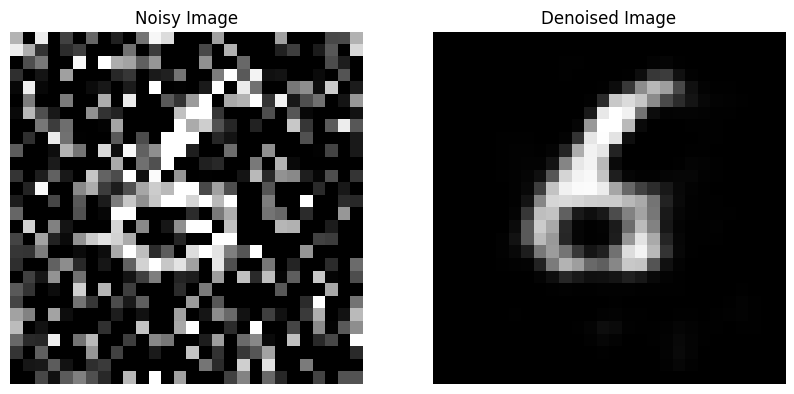

In [94]:
# Encode the noisy image
encoded_img_noisy = encoder.predict(img_array_noisy)
print("Encoded noisy image shape:", encoded_img_noisy.shape)

# Decode the noisy image to get the denoised image
denoised_img = decoder.predict(encoded_img_noisy)
print("Denoised image shape:", denoised_img.shape)

# Display noisy and denoised image
plt.figure(figsize=(10, 5))

ax = plt.subplot(1, 2, 1)
plt.imshow(img_array_noisy.reshape(28, 28), cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

ax = plt.subplot(1, 2, 2)
plt.imshow(denoised_img.reshape(28, 28), cmap='gray')
plt.title('Denoised Image')
plt.axis('off')

plt.show()